In [ ]:
!python -mpip install pandas numpy matplotlib ipympl # needs to reboot jupyter server if ipympl isn't working

Use the following for an interactive figure

In [2]:
%matplotlib ipympl

or the following for a direct inline figure.

In [3]:
%matplotlib inline

In [4]:
from pathlib import Path

path_to_data = Path("data-main-text")

Explicitly choose an accessible colormap.

In [5]:
colors=["#C70070", "#D7333B", "#E2A300", "#52BD7C", "#44ACE8", "#555555"]

Import numpy, pandas and matplotlib. Set font-size and latex mode.

In [6]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib
params = {'text.usetex' : True,
          'font.size' : 14,
          'font.family' : 'lmodern',
          }
plt.rcParams.update(params) 

Label the data to be imported for CPU and GPU

In [7]:
cpu_data = "sw-for-loop.cpu-echo.csv"
gpu_data = "sw-for-loop.gpu-echo.csv"
out_data = "sw-for-loop_echo.pdf"

Import the CSV data into a pandas dataframe

In [8]:
df_cpu = pd.read_csv(path_to_data / cpu_data, skiprows=[0,1])
df_gpu = pd.read_csv( path_to_data / gpu_data, skiprows=[0,1])

Extract the stats with percentiles we care about, and track them for later reuse.

In [9]:
df_cpu

,sample,rtt_cycles,rtt_us
0,0,928,4.640
1,1,465,2.325
2,2,482,2.410
3,3,460,2.300
4,4,468,2.340
...,...,...,...
999995,999995,460,2.300
999996,999996,462,2.310
999997,999997,460,2.300
999998,999998,463,2.315


In [15]:
df_cpu_desc = df_cpu['rtt_us'].describe(percentiles=[0.5, 0.99, 0.999, 0.99999])
df_gpu_desc = df_gpu['rtt_us'].describe(percentiles=[0.5, 0.99, 0.999, 0.99999])
df_cpu_desc, df_gpu_desc

(count      999999.000000
 mean            2.312325
 std             0.021373
 min             2.285000
 50%             2.305000
 99%             2.420000
 99.9%           2.445000
 99.999%         2.475000
 max             2.590000
 Name: rtt_us, dtype: float64,
 count      999999.000000
 mean            4.448307
 std             0.159053
 min             4.200000
 50%             4.500000
 99%             4.985000
 99.9%           5.125000
 99.999%         5.255000
 max             5.285000
 Name: rtt_us, dtype: float64)

To allow us to display the important stats as part of the plot generation, we can write a function to extract and format the string data correctly.

In [35]:
def build_label(df, percentiles = [0.5, 0.99, 0.999, 0.99999] ):
    """This function takes a given data-frame, and a set of percentiles to use, and 
    constructs a string that is formatted for display in the legend field of the plots.
    The t_0 entry represents the excluded initial warmup value from the sampled data.
    """

    max_t0 = df['rtt_us'].describe(percentiles=percentiles)["max"]
    desc_ss = df['rtt_us'].iloc[1:].describe(percentiles=percentiles)
    str=f"""mean={desc_ss["mean"]:.4g} $\\mu$s
    std=\t{desc_ss["std"]:.4g} $\\mu$s
    med=\t{desc_ss["50%"]:.4g} $\\mu$s
    min=\t{desc_ss["min"]:.4g} $\\mu$s
    max=\t{desc_ss["max"]:.4g} $\\mu$s
    $t_0$=\t{max_t0:.4g} $\\mu$s
    P99=\t{desc_ss['99%']:.4g} $\\mu$s
    P99.9=\t{desc_ss["99.9%"]:.4g} $\\mu$s
    P99.999=\t{desc_ss["99.999%"]:.4g} $\\mu$s"""
    return str


A sample output:

In [36]:
build_label(df_cpu)

'mean=2.312 $\\mu$s\n    std=\t0.02137 $\\mu$s\n    med=\t2.305 $\\mu$s\n    min=\t2.285 $\\mu$s\n    max=\t2.59 $\\mu$s\n    $t_0$=\t4.64 $\\mu$s\n    P99=\t2.42 $\\mu$s\n    P99.9=\t2.445 $\\mu$s\n    P99.999=\t2.475 $\\mu$s'

We can now build the histograms of the data in a 2x1 (RxC) format, showcasing the CPU and the GPU. Both use different scales on the x-axis due to the change in floors and ceilings, but maintain a fixed ylim for both. Counts are reported instead of densities. The histogram will be saved to `path_to_data` with the titles taken from ( `hist_`, `scatter_`), and `out_data` as PDF output.

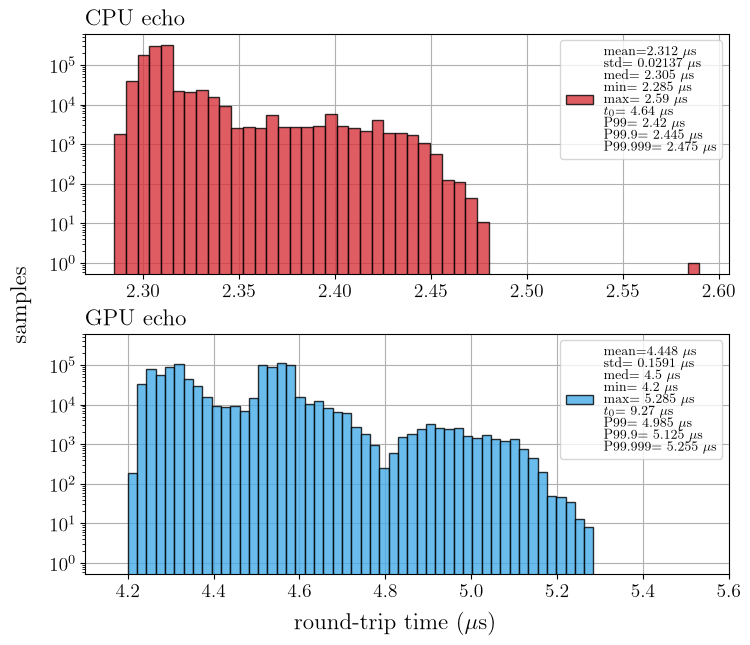

In [37]:
# Create fig and layout as 2x1
matplotlib.rcParams.update({'font.size': 14})
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(7,6), sharex=False, sharey=True, layout="constrained")

# CPU, excluding initial value treated as a warmup
df_cpu.iloc[1:].hist(column="rtt_us", bins = 50, log = True, color=colors[1], alpha=0.8, ec='black', lw=1, ax=ax1, label=build_label(df_cpu))
ax1.set_title("")
ax1.set_title("$\\textrm{CPU echo}$", loc="left")
ax1.legend(loc="upper right", fontsize="x-small", ncol=2)
ax1.set_axisbelow(True)

# GPU, excluding initial value treated as a warmup
df_gpu.iloc[1:].hist(column="rtt_us", bins = 50, log = True, color=colors[-2], alpha=0.8,ec='black', lw=1, ax=ax2,  label=build_label(df_gpu))
ax2.set_title("")
ax2.set_title("$\\textrm{GPU echo}$", loc="left")
ax2.legend(loc="upper right", fontsize="x-small", ncol=2)
ax2.set_axisbelow(True)
ax2.set_xlim([4.1, 5.6])


fig.supxlabel("$\\textrm{round-trip time}$ ($\\mu$s)", y=-0.05)
fig.supylabel("$\\textrm{samples}$", x=-0.05)

plt.savefig(path_to_data / ("hist_steadystate_"+out_data), bbox_inches='tight')

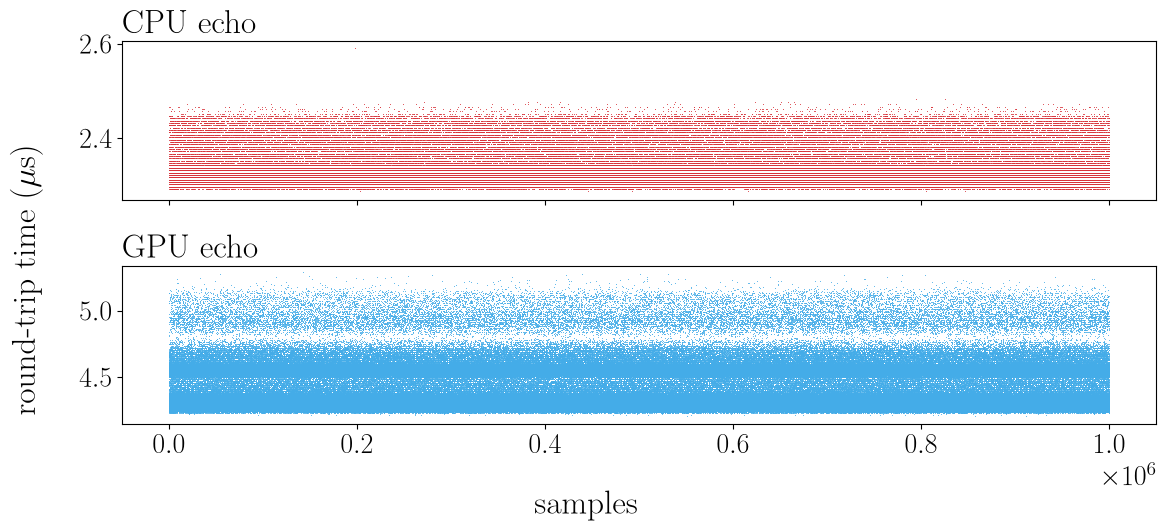

In [38]:
# CPU
matplotlib.rcParams.update({'font.size': 20})
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,6), sharex=True, sharey=False)

ax1.plot(df_cpu["sample"].iloc[1:], df_cpu["rtt_us"].iloc[1:], ',', markersize=0.5,  alpha=0.8, color=colors[1], linewidth=1, rasterized=True)
ax1.set_title("")
ax1.set_title("$\\textrm{CPU echo}$", loc="left")


# GPU
ax2.plot(df_gpu["sample"].iloc[1:], df_gpu["rtt_us"].iloc[1:], ',', markersize=0.5,  alpha=0.8, color=colors[-2], linewidth=1, rasterized=True)
ax2.set_title("")
ax2.set_title("$\\textrm{GPU echo}$", loc="left")

fig.supylabel("$\\textrm{round-trip time}$ ($\\mu$s)", x=0.02)
fig.supxlabel("$\\textrm{samples}$", y=0.1)

fig.tight_layout()
plt.savefig(path_to_data / ("scatter_steadystate"+out_data),  bbox_inches='tight')